In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *

# Transform to tensor
dataset_transform = transforms.Compose([
    transforms.ToTensor(),                 
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalization 
])

train_dataset = datasets.MNIST(
    root = "./data",      
    train = True,         
    download = True,      
    transform = dataset_transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,        
    download = True,
    transform = dataset_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    

model1 = Model1()


# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model1.parameters(), lr=0.1, momentum=0.9)

train_data_size = len(train_dataset)
test_data_size = len(test_dataset)

In [3]:
epoch = 5

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for data in train_loader:
        imgs, targets = data
        outputs = model1(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    with torch.no_grad():
        for data in test_loader:
            imgs, targets = data
            outputs = model1(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy
    
    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / test_data_size))

-------Epoch 1-------
Total loss in test set: 1.3666119948029518
Total accuracy in test set: 0.9564
-------Epoch 2-------
Total loss in test set: 1.152989149093628
Total accuracy in test set: 0.9666
-------Epoch 3-------
Total loss in test set: 1.057379089295864
Total accuracy in test set: 0.9686
-------Epoch 4-------
Total loss in test set: 1.1422982104122639
Total accuracy in test set: 0.9693
-------Epoch 5-------
Total loss in test set: 1.1670173443853855
Total accuracy in test set: 0.9705


In [4]:
X = build_pruning_matrix(train_loader)
ratios = np.linspace(0.1, 0.9, 9)
base_acc = total_accuracy / test_data_size

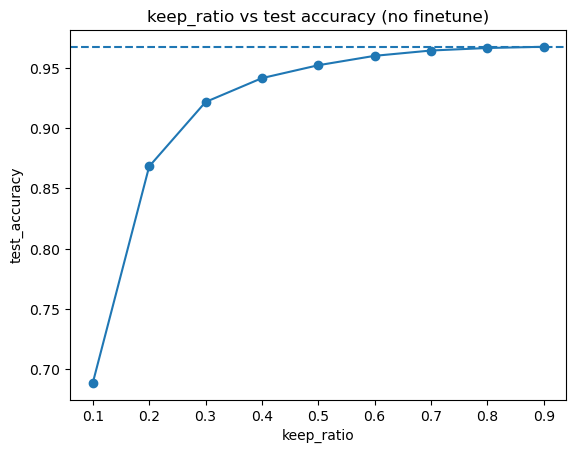

In [14]:
methods = ["StrongRRQR"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        coeffs, biases, p, T = prune_model(model1, X, r, method=method)
        _, acc = evaluate_pruned(coeffs, biases, test_loader, device)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")

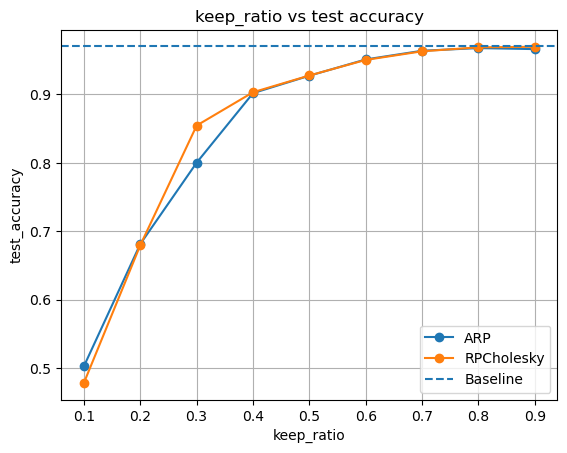

In [14]:
methods = ["ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        coeffs, biases, p, T = prune_model(model1, X, r, method=method)
        _, acc = evaluate_pruned(coeffs, biases, test_loader, device)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")

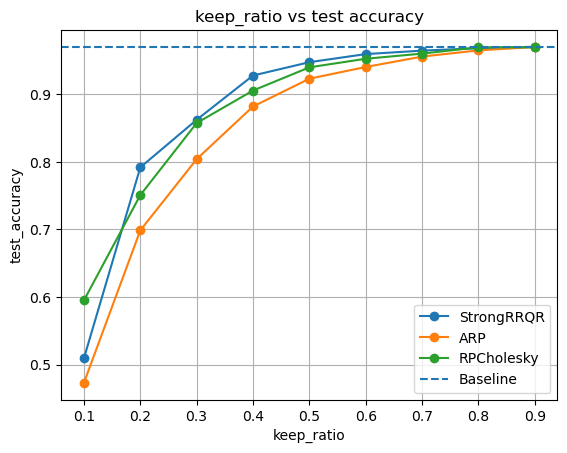

In [11]:
methods = ["StrongRRQR", "ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        coeffs, biases, p, T = prune_model(model1, X, r, method=method)
        _, acc = evaluate_pruned(coeffs, biases, test_loader, device)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")